In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

from dataset import SceneTwoPairsDataset
from colmap_pair_dataset import ColmapPairDataset
from model import PairImageCylinderModel
from losses import supervised_loss, matched_radius_consistency_loss, matched_reprojection_loss_2d
from train_utils import move_two_pair_batch_to_device, compute_two_pair_losses, compute_forest_losses

from debugger import bug_check


In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA available: True
NVIDIA GeForce RTX 5050 Laptop GPU


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = PairImageCylinderModel(
    img_size=128,
    patch_size=8,
    in_chans=3,
    embed_dim=384,
    depth=6,
    num_heads=6,
    num_bins=128,
    dropout=0.1,
).to(device)


In [5]:
BATCH_SIZE = 16

train_dataset = SceneTwoPairsDataset(
    root_dir="dataset",
    image_size=128,
    debug=False,
    return_two_pairs=True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_dataset = SceneTwoPairsDataset(
    root_dir="valdataset",
    image_size=128,
    debug=False,
    return_two_pairs=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

forest_dataset = ColmapPairDataset(
    dataset_dir="forestdataset",
    image_size=128,
)

forest_loader = DataLoader(
    forest_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

In [6]:
# bug_check(0)

import torch.nn.functional as F

from losses import match_sinkhorn_between_views


if True:
    debug_dataset = SceneTwoPairsDataset(
        root_dir="dataset",
        return_two_pairs=False
    )

    debug_loader = DataLoader(
        debug_dataset,
        batch_size=4,
        shuffle=False,
        num_workers=0,
    )


    batch = next(iter(debug_loader))
    img_a, vision_a, img_b, vision_b, pose_ab = batch

    batch_forest = next(iter(forest_loader))
    img_a_forest, img_b_forest, pose_forest = batch_forest

    print("img_a_forest shape:", img_a_forest.shape)
    print("img_b_forest shape:", img_b_forest.shape)
    print("pose_forest shape:", pose_forest.shape)


img_a_forest shape: torch.Size([16, 3, 128, 128])
img_b_forest shape: torch.Size([16, 3, 128, 128])
pose_forest shape: torch.Size([16, 4, 4])


In [7]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# Hyperparameters
NUM_EPOCHS = 500
VAL_INTERVAL = 5
FOREST_START_EPOCH = 50

LAMBDA_OCC = 10.0
LAMBDA_RADIUS = 10.0
OCC_THRESH = 0.5

LAMBDA_REPROJ = 5.0
LAMBDA_RAD = 10.0

history = {
    "epoch": [],
    "total": [],
    "supervised": [],
    "vision": [],
    "pose": [],
    "radius_consistency": [],
    "reprojection": [],
    "forest_total": [],
    "forest_radius_consistency": [],
    "forest_reprojection": [],
    "val_epoch": [],
    "val_total": [],
    "val_supervised": [],
    "val_vision": [],
    "val_pose": [],
    "val_radius_consistency": [],
    "val_reprojection": [],
}

def run_epoch(data_loader, training, loss_fn):
    if training:
        model.train()
    else:
        model.eval()

    totals = {
        "total": 0.0,
        "supervised": 0.0,
        "vision": 0.0,
        "pose": 0.0,
        "radius_consistency": 0.0,
        "reprojection": 0.0,
    }

    with torch.set_grad_enabled(training):
        for batch in data_loader:
            if training:
                optimizer.zero_grad(set_to_none=True)

            loss, metrics = loss_fn(batch, model, device)

            if training:
                loss.backward()
                optimizer.step()

            for key in totals:
                totals[key] += metrics[key]

    n = len(data_loader)
    return {key: value / n for key, value in totals.items()}


for epoch in range(NUM_EPOCHS):
    epoch_num = epoch + 1

    train_metrics = run_epoch(
        train_loader,
        training=True,
        loss_fn=compute_two_pair_losses,
    )

    forest_metrics = None

    if epoch_num >= FOREST_START_EPOCH:
        forest_metrics = run_epoch(
            forest_loader,
            training=True,
            loss_fn=compute_forest_losses,
        )

    history["epoch"].append(epoch_num)
    history["total"].append(train_metrics["total"])
    history["supervised"].append(train_metrics["supervised"])
    history["vision"].append(train_metrics["vision"])
    history["pose"].append(train_metrics["pose"])
    history["radius_consistency"].append(train_metrics["radius_consistency"])
    history["reprojection"].append(train_metrics["reprojection"])

    if forest_metrics is not None:
        history["forest_total"].append(forest_metrics["total"])
        history["forest_radius_consistency"].append(forest_metrics["radius_consistency"])
        history["forest_reprojection"].append(forest_metrics["reprojection"])
    else:
        history["forest_total"].append(None)
        history["forest_radius_consistency"].append(None)
        history["forest_reprojection"].append(None)

    log = (
        f"Epoch {epoch_num}: "
        f"tot={train_metrics['total']:.4f} | "
        f"sup={train_metrics['supervised']:.4f} | "
        f"vis={train_metrics['vision']:.4f} | "
        f"pose={train_metrics['pose']:.4f} | "
        f"radius_cons={train_metrics['radius_consistency']:.4f} | "
        f"reproj={train_metrics['reprojection']:.4f}"
    )

    if forest_metrics is not None:
        log += (
            f" | forest_tot={forest_metrics['total']:.4f} | "
            f"forest_radius_cons={forest_metrics['radius_consistency']:.4f} | "
            f"forest_reproj={forest_metrics['reprojection']:.4f}"
        )

    if epoch_num == 1 or epoch_num % VAL_INTERVAL == 0:
        val_metrics = run_epoch(
            val_loader,
            training=False,
            loss_fn=compute_two_pair_losses,
        )

        history["val_epoch"].append(epoch_num)
        history["val_total"].append(val_metrics["total"])
        history["val_supervised"].append(val_metrics["supervised"])
        history["val_vision"].append(val_metrics["vision"])
        history["val_pose"].append(val_metrics["pose"])
        history["val_radius_consistency"].append(val_metrics["radius_consistency"])
        history["val_reprojection"].append(val_metrics["reprojection"])

        log += (
            f" | val_tot={val_metrics['total']:.4f} | "
            f"val_sup={val_metrics['supervised']:.4f} | "
            f"val_vis={val_metrics['vision']:.4f} | "
            f"val_pose={val_metrics['pose']:.4f} | "
            f"val_radius_cons={val_metrics['radius_consistency']:.4f} | "
            f"val_reproj={val_metrics['reprojection']:.4f}"
        )

    print(log)

Epoch 1: tot=21.0287 | sup=21.0287 | vis=20.6888 | pose=0.3378 | radius_cons=0.0198 | reproj=0.0167 | val_tot=19.8624 | val_sup=19.8624 | val_vis=19.6546 | val_pose=0.2560 | val_radius_cons=0.0001 | val_reproj=0.0006
Epoch 2: tot=19.1353 | sup=19.1353 | vis=18.8941 | pose=0.2567 | radius_cons=0.0168 | reproj=0.0074
Epoch 3: tot=17.6630 | sup=17.6630 | vis=17.4124 | pose=0.2563 | radius_cons=0.0038 | reproj=0.0002
Epoch 4: tot=16.3664 | sup=16.3664 | vis=16.1360 | pose=0.2566 | radius_cons=0.0000 | reproj=0.0000
Epoch 5: tot=14.9152 | sup=14.9152 | vis=14.6778 | pose=0.2568 | radius_cons=0.0000 | reproj=0.0000 | val_tot=14.2662 | val_sup=14.2662 | val_vis=14.0972 | val_pose=0.2563 | val_radius_cons=0.0000 | val_reproj=0.0000
Epoch 6: tot=13.0719 | sup=13.0719 | vis=12.8213 | pose=0.2565 | radius_cons=0.0000 | reproj=0.0000
Epoch 7: tot=11.1605 | sup=11.1605 | vis=10.9036 | pose=0.2564 | radius_cons=0.0000 | reproj=0.0000
Epoch 8: tot=9.8943 | sup=9.8943 | vis=9.6360 | pose=0.2571 | radi

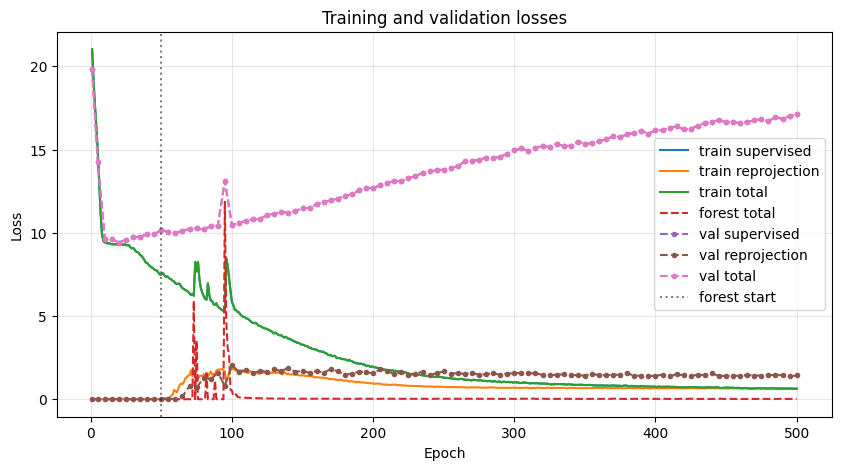

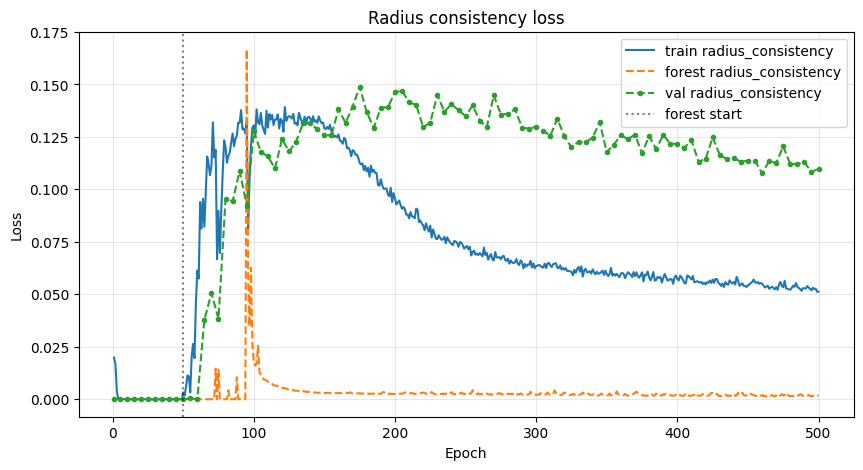

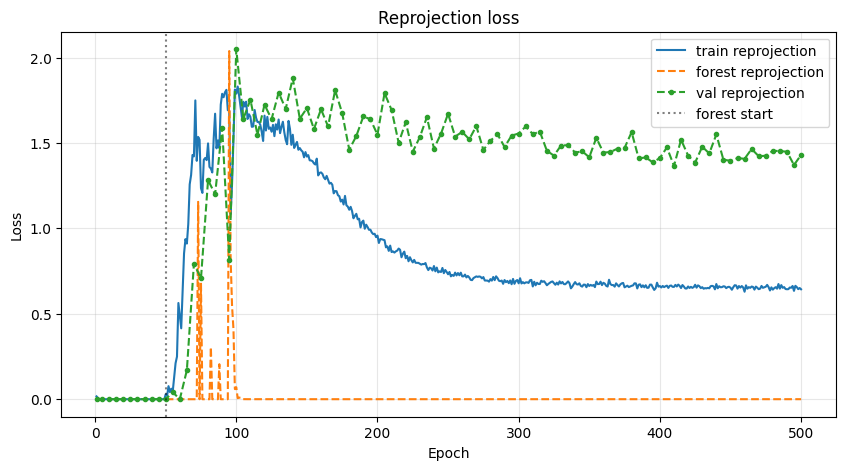

In [8]:
# Plot efter träning
epochs = np.array(history["epoch"])
val_epochs = np.array(history["val_epoch"])

plt.figure(figsize=(10, 5))
plt.plot(epochs, history["supervised"], label="train supervised")
plt.plot(epochs, history["reprojection"], label="train reprojection")
plt.plot(epochs, history["total"], label="train total")
plt.plot(epochs, history["forest_total"],"--",label="forest total")

if len(val_epochs) > 0:
    plt.plot(val_epochs, history["val_supervised"], ".--", label="val supervised")
    plt.plot(val_epochs, history["val_reprojection"], ".--", label="val reprojection")
    plt.plot(val_epochs, history["val_total"], ".--", label="val total")

plt.axvline(FOREST_START_EPOCH,color="k",linestyle=":",alpha=0.5,label="forest start")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation losses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(epochs, history["radius_consistency"], label="train radius_consistency")
plt.plot(epochs, history["forest_radius_consistency"],"--", label="forest radius_consistency")

if len(val_epochs) > 0:
    plt.plot(val_epochs, history["val_radius_consistency"],".--", label="val radius_consistency")

plt.axvline(FOREST_START_EPOCH,color="k",linestyle=":",alpha=0.5,label="forest start")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Radius consistency loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(epochs, history["reprojection"],label="train reprojection")
plt.plot(epochs, history["forest_reprojection"],"--",label="forest reprojection")

if len(val_epochs) > 0:
    plt.plot(val_epochs, history["val_reprojection"],".--",label="val reprojection")

plt.axvline(FOREST_START_EPOCH,color="k",linestyle=":",alpha=0.5,label="forest start")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Reprojection loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# Inference + utskrift + plottar på samma dataset som träningen
from utils import pose_to_text, show_image_pair

infer_dataset = SceneTwoPairsDataset(
    root_dir="testdataset",
    return_two_pairs=False
)

infer_loader = DataLoader(
    infer_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
)
model.eval()

batch = next(iter(infer_loader))
img_a, vision_a, img_b, vision_b, pose_ab = batch

img_a = img_a.to(device)
vision_a = vision_a.to(device)
img_b = img_b.to(device)
vision_b = vision_b.to(device)
pose_ab = pose_ab.to(device)

with torch.no_grad():
    pred_vision, _, pred_pose = model(img_a, img_b)

if False:
    # Skriv ut resultat för några samples
    n_show = min(4, img_a.shape[0])
    for i in range(n_show):
        print(f"Sample {i}")
        print("  GT   pose:", pose_to_text(pose_ab[i].detach().cpu()))
        print("  Pred pose:", pose_to_text(pred_pose[i].detach().cpu()))

        pose_err = torch.abs(pred_pose[i] - pose_ab[i]).detach().cpu()
        print(f"  |err|     : tx={pose_err[0]:.3f}, ty={pose_err[1]:.3f}, sin={pose_err[2]:.3f}, cos={pose_err[3]:.3f}")
        print()

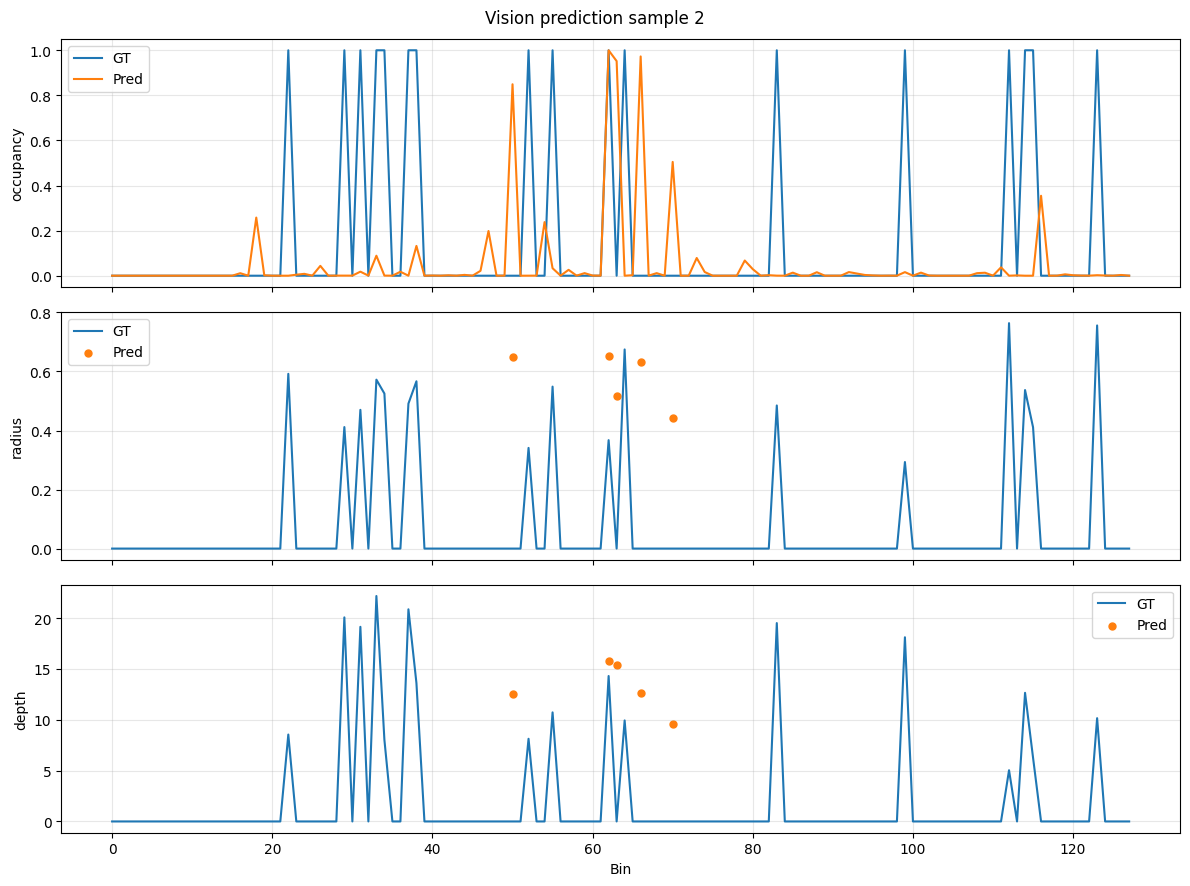

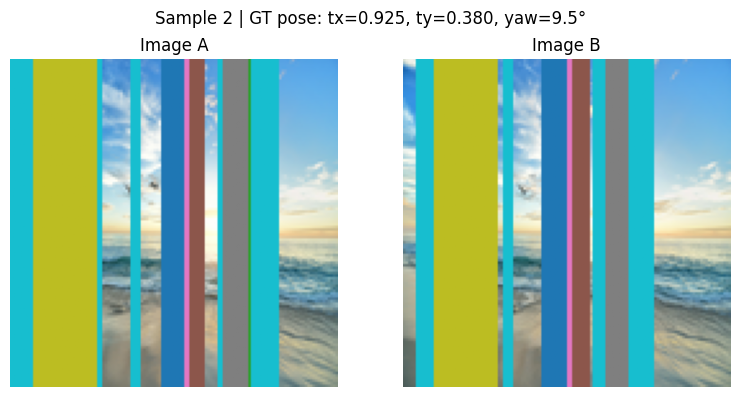

In [13]:
# Plotta vision-output för första samplet
sample_idx = 2
bins = np.arange(pred_vision.shape[1])

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

names = ["occupancy", "radius", "depth"]
occ_threshold = 0.4

gt_occ = vision_a[sample_idx, :, 0].detach().cpu().numpy()
pr_occ = pred_vision[sample_idx, :, 0].detach().cpu().numpy()

for j, ax in enumerate(axes):
    gt = vision_a[sample_idx, :, j].detach().cpu().numpy()
    pr = pred_vision[sample_idx, :, j].detach().cpu().numpy()

    # GT alltid blå linje
    ax.plot(bins, gt, label="GT", color="tab:blue")

    if j == 0:
        # occupancy: pred som orange linje
        ax.plot(bins, pr, label="Pred", color="tab:orange")
    else:
        pr_mask = pr_occ > occ_threshold

        # pred som orange punkter
        ax.scatter(
            bins[pr_mask],
            pr[pr_mask],
            label="Pred",
            color="tab:orange",
            s=25
        )

    ax.set_ylabel(names[j])
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Bin")
fig.suptitle(f"Vision prediction sample {sample_idx}")
plt.tight_layout()
plt.show()

# Plotta bildpar
show_image_pair(
    img_a[sample_idx].detach().cpu(),
    img_b[sample_idx].detach().cpu(),
    title=f"Sample {sample_idx} | GT pose: {pose_to_text(pose_ab[sample_idx].detach().cpu())}"
)

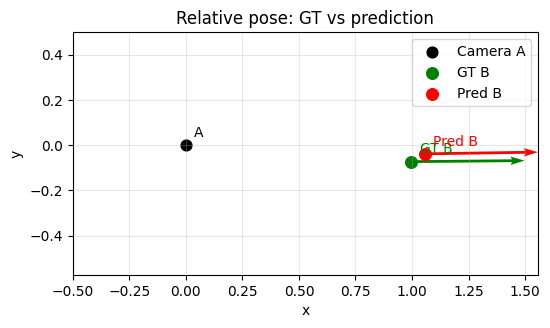

pred_vision shape: torch.Size([4, 128, 3])
pred_pose shape: torch.Size([4, 4])
GT pose: tensor([ 0.9974, -0.0725,  0.0090,  1.0000])
Pred pose: tensor([ 1.0559, -0.0381,  0.0151,  0.9999])


In [11]:
import matplotlib.pyplot as plt
import torch
import numpy as np

from utils import plot_relative_pose


# Visa första paret i batchen
if False:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(img_a[sample_idx].cpu().permute(1, 2, 0))
    axes[0].set_title("Image A")
    axes[0].axis("off")

    axes[1].imshow(img_b[sample_idx].cpu().permute(1, 2, 0))
    axes[1].set_title("Image B")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# Visa relative pose
plot_relative_pose(pose_ab[sample_idx], pred_pose[sample_idx])

print("pred_vision shape:", pred_vision.shape)
print("pred_pose shape:", pred_pose.shape)
print("GT pose:", pose_ab[sample_idx].detach().cpu())
print("Pred pose:", pred_pose[sample_idx].detach().cpu())